/Users/rbrady0110/micromamba/envs/doubles/lib/python3.13/site-packages/lenstronomy/Data/psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(
/Users/rbrady0110/micromamba/envs/doubles/lib/python3.13/site-packages/lenstronomy/Plots/model_band_plot.py:68: RuntimeWarning: divide by zero encountered in log10
  log_model = np.log10(model)
/Users/rbrady0110/micromamba/envs/doubles/lib/python3.13/site-packages/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),
/Users/rbrady0110/micromamba/envs/doubles/lib/python3.13/site-packages/lenstronomy/Plots/model_band_plot.py:225: RuntimeWarning: divide by zero encountered in log10
  np.log10(self._model),


-1.0266426720593884 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  0.8265226377824798
reduced chi^2 of data  1 =  0.9407584824306015
reduced chi^2 of data  2 =  1.250143176504044
-1.0266426720593884 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  0.8265226377824798
reduced chi^2 of data  1 =  0.9407584824306015
reduced chi^2 of data  2 =  1.250143176504044
-1.0266426720593884 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  0.8265226377824798
reduced chi^2 of data  1 =  0.9407584824306015
reduced chi^2 of data  2 =  1.250143176504044


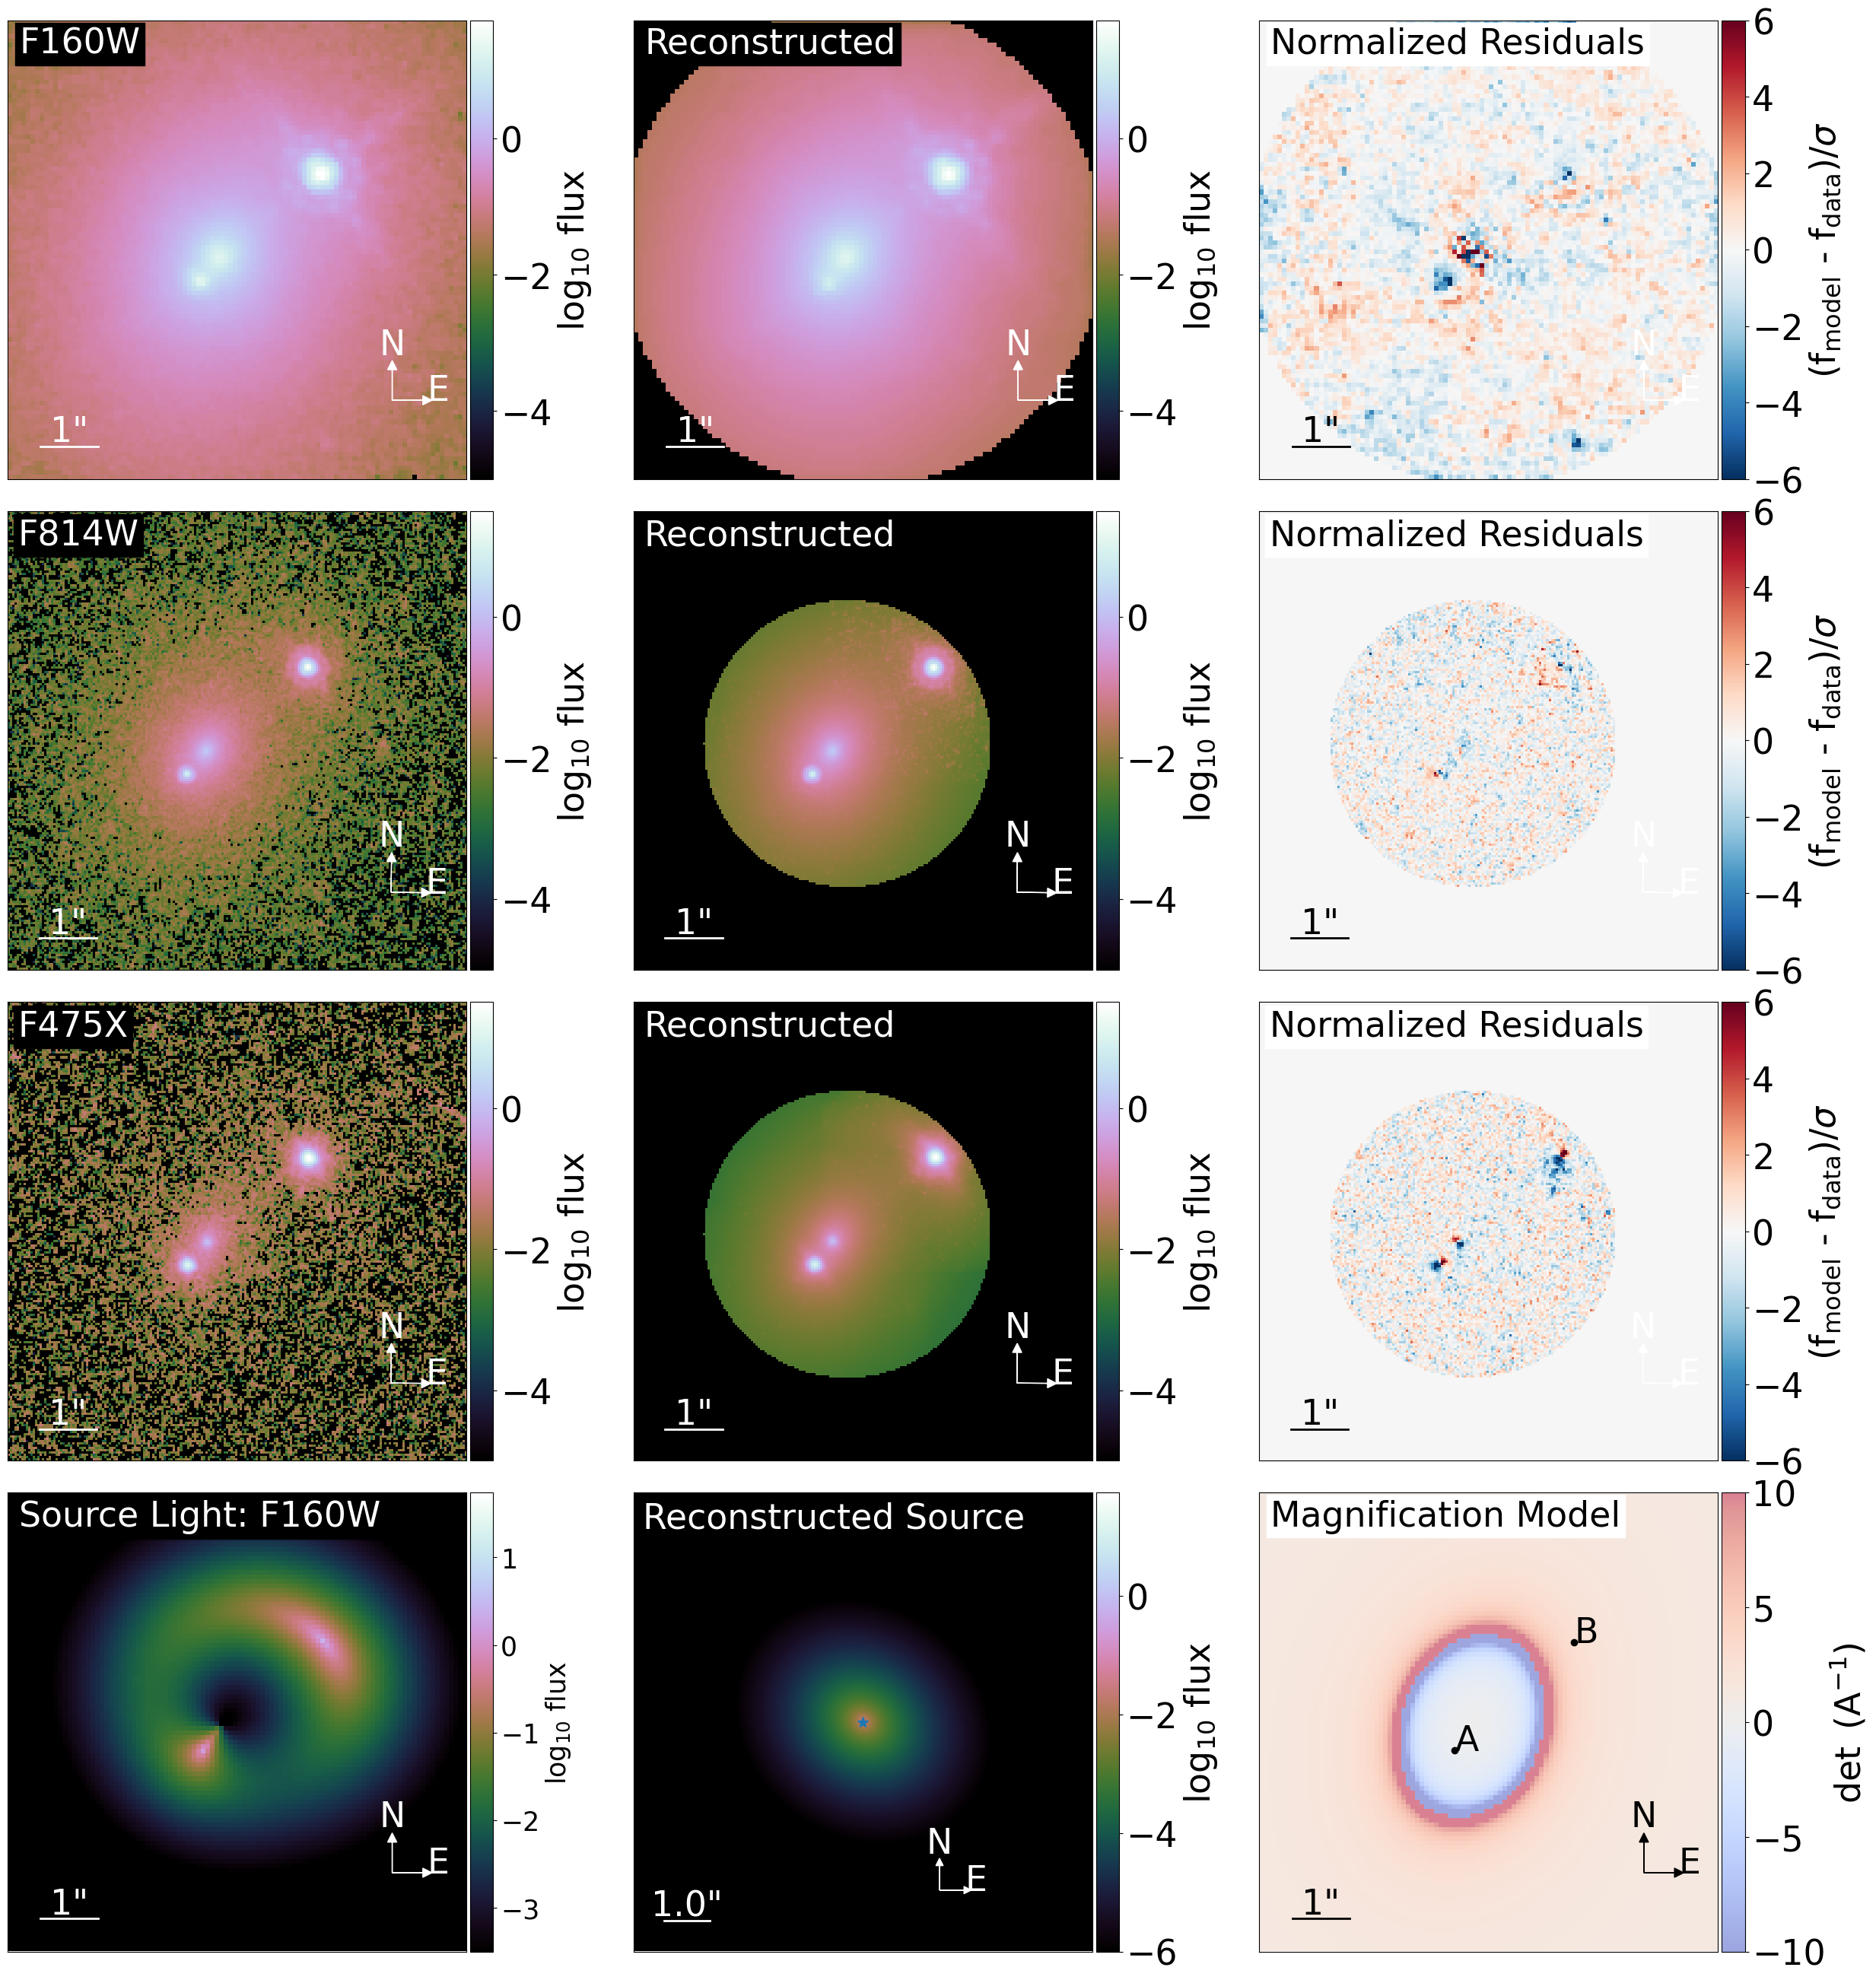

In [1]:
	
import pickle
import matplotlib.pyplot as plt
from lenstronomy.Plots.model_plot import ModelPlot

# define filters and system name
name = 'J1620+1203'
filters = ['F160W', 'F814W', 'F475X']
fontsize = 33

nrows = len(filters) + 1
fig, axes = plt.subplots(nrows, 3, figsize=(25, 26))

for i, filter in enumerate(filters):
    filename = f"../joint_modeling/{name}/{name}_joint.pkl"

    with open(filename, "rb") as f:
        loaded_data = pickle.load(f)

    kwargs_result = loaded_data["kwargs_result"]
    multi_band_list = loaded_data["multi_band_list"]
    kwargs_model = loaded_data["kwargs_model"]
    mask_list = loaded_data['kwargs_likelihood']['image_likelihood_mask_list']

    # initialize model plot
    modelPlot = ModelPlot(multi_band_list, kwargs_model, kwargs_result, image_likelihood_mask_list=mask_list, arrow_size=0.02, cmap_string="cubehelix")

    # plot data image
    modelPlot.data_plot(ax=axes[i, 0],text=f'{filter}',font_size=fontsize, band_index=i,)
    # plot model image
    modelPlot.model_plot(ax=axes[i, 1],font_size=fontsize, band_index=i)

    # plot residuals
    modelPlot.normalized_residual_plot(ax=axes[i, 2],v_min=-6,v_max=6,font_size=fontsize, band_index=i, cmap='RdBu_r')

    if i == 0:
            modelPlot.decomposition_plot(
            ax=axes[3, 0], 
            text="Source Light: F160W", 
            font_size = 25,
            source_add=True, 
            unconvolved=True, 
            v_min=-3.5,
            band_index=i
                )
            
            modelPlot.source_plot(
            ax=axes[3, 1], text="Reconstructed Source", deltaPix_source=0.01, numPix=1000, v_min = -6., scale_size = 1, font_size = fontsize, band_index=0
            )    
            modelPlot.magnification_plot(ax=axes[3, 2], text='Magnification Model', cmap='coolwarm', font_size = fontsize, band_index=i)
            

    # plot magnification model
    #modelPlot.magnification_plot(ax=axes[i, 3],text='Magnification Model', font_size=fontsize, cmap='PiYG')

    for sub_ax in axes[i+1, 0].figure.axes:
        for text in sub_ax.texts:
            text.set_fontsize(fontsize)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15, hspace=0.07)
#plt.savefig(f'{name}_model.png')
plt.show()


# Create 2 x 2 Grid for Other Models

-1.5691278090313105 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  2.3238652479081074
reduced chi^2 of data  1 =  1.568170840929682
reduced chi^2 of data  2 =  1.1451848831087879
-1.5691278090313105 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  2.3238652479081074
reduced chi^2 of data  1 =  1.568170840929682
reduced chi^2 of data  2 =  1.1451848831087879
-1.5691278090313105 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  2.3238652479081074
reduced chi^2 of data  1 =  1.568170840929682
reduced chi^2 of data  2 =  1.1451848831087879
-1.3869773913861485 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  2.679519356233751
reduced chi^2 of data  1 =  0.9585267501259536
reduced chi^2 of data  2 =  0.974081512

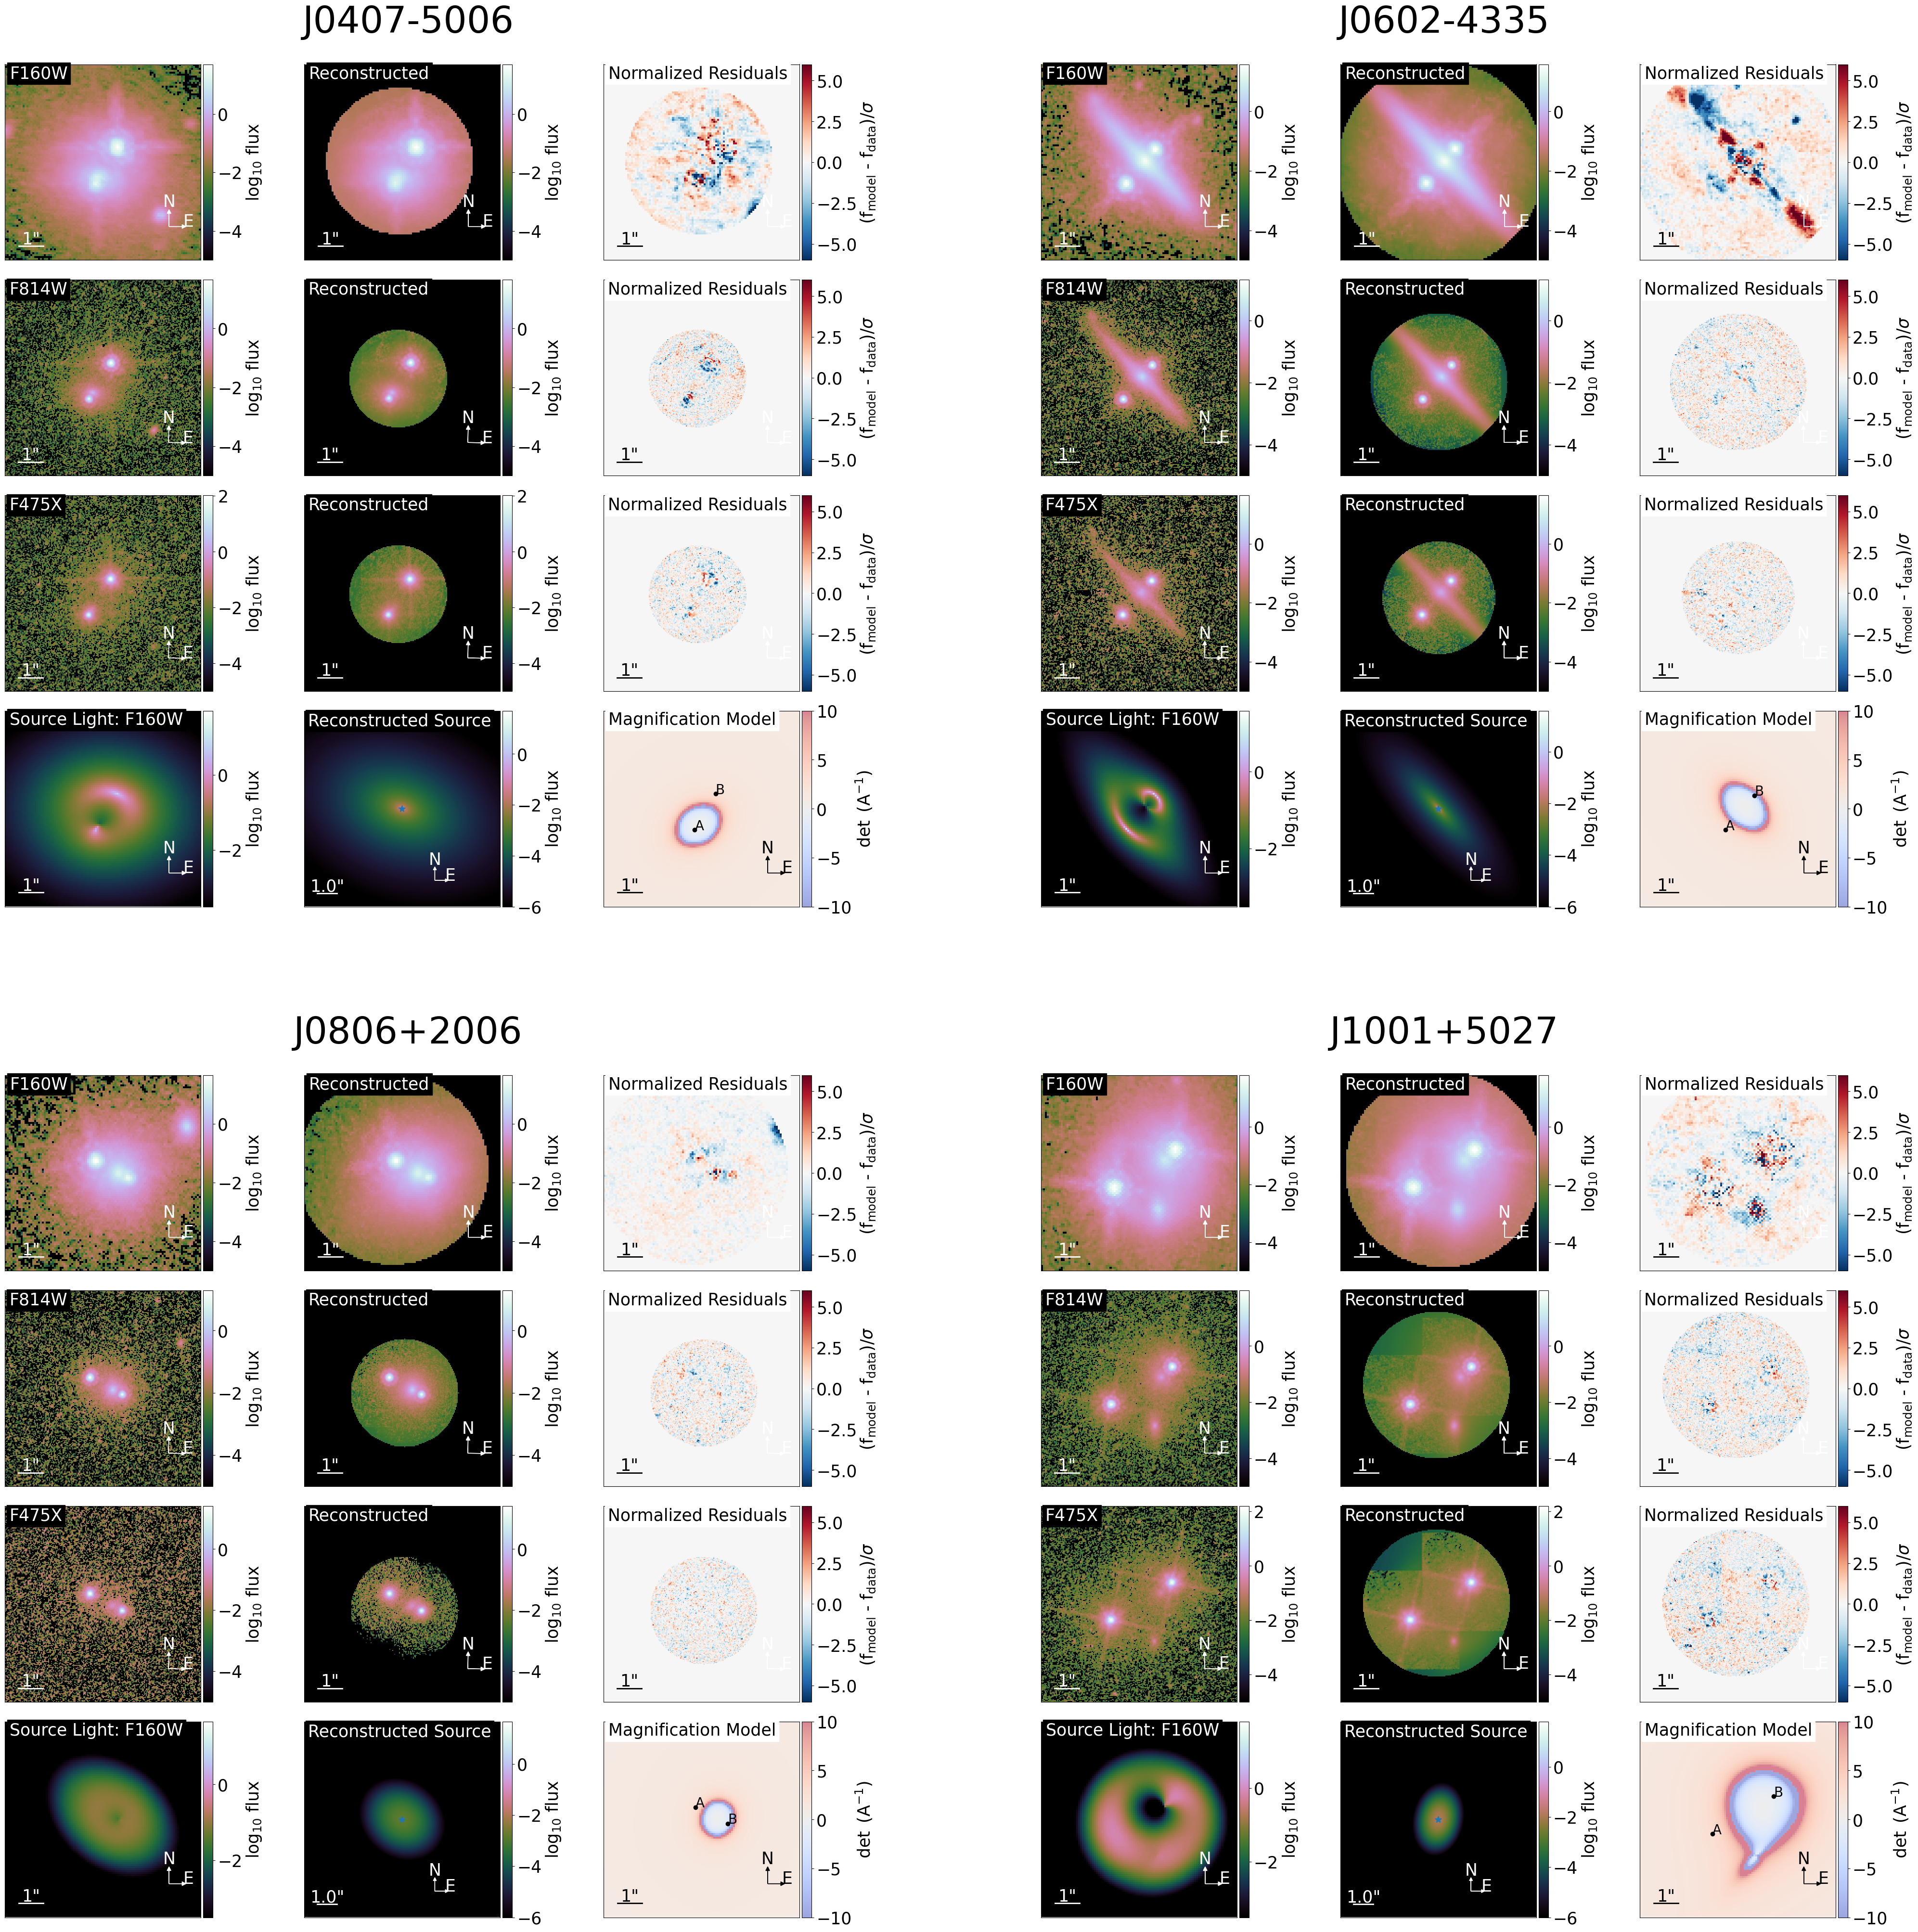

In [5]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from lenstronomy.Plots.model_plot import ModelPlot
import matplotlib.gridspec as gridspec

# Define systems and filters
systems = [
    ['J0407-5006', 'J0602-4335'],   # top row: left, right
    ['J0806+2006', 'J1001+5027']    # bottom row: left, right
]
filters = ['F160W', 'F814W', 'F475X']
fontsize = 25

# Create figure and outer GridSpec (2x2) that controls block spacing 
fig = plt.figure(figsize=(50, 50))

# outer 2x2 grid: adjust these to increase/decrease space between blocks
outer_gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    wspace=0.25,   # large horizontal gap between left/right blocks
    hspace=0.2    # large vertical gap between top/bottom blocks
)

# Loop through each outer cell (each system)
for row_block, system_pair in enumerate(systems):
    for col_block, name in enumerate(system_pair):
        # Create a 4x3 inner GridSpec inside the outer cell (tight spacing inside block)
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            4, 3,
            subplot_spec=outer_gs[row_block, col_block],
            wspace=0.3,   # small horizontal spacing inside a block
            hspace=0.1   # small vertical spacing inside a block
        )

        # Get bounding box of the outer grid cell
        bbox = outer_gs[row_block, col_block].get_position(fig)

        # Add system name centered above the block
        fig.text(
            x=0.5 * (bbox.x0 + bbox.x1),
            y=bbox.y1 + 0.01,   # small vertical offset above block
            s=name,
            ha='center',
            va='bottom',
            fontsize=55,
            #fontweight='bold'
        )

        # Fill the inner grid with axes
        # Rows 0-2: filter rows (data, model, residual) for each filter
        # Row 3: decomposition/convergence/magnification
        for i, filter in enumerate(filters):
            # Row index in inner grid for this filter
            inner_row = i

            # Prepare data
            filename = f"../joint_modeling/{name}/{name}_joint.pkl"
            with open(filename, "rb") as f:
                loaded_data = pickle.load(f)

            kwargs_result = loaded_data["kwargs_result"]
            multi_band_list = loaded_data["multi_band_list"]
            kwargs_model = loaded_data["kwargs_model"]
            mask_list = loaded_data['kwargs_likelihood']['image_likelihood_mask_list']

            modelPlot = ModelPlot(
                multi_band_list,
                kwargs_model,
                kwargs_result,
                image_likelihood_mask_list=mask_list,
                arrow_size=0.02,
                cmap_string="cubehelix"
            )

            # Create axes in the inner grid: column 0=data, col1=model, col2=residual
            ax_data = fig.add_subplot(inner_gs[inner_row, 0])
            ax_model = fig.add_subplot(inner_gs[inner_row, 1])
            ax_resid = fig.add_subplot(inner_gs[inner_row, 2])

            modelPlot.data_plot(
                ax=ax_data,
                text=f'{filter}',
                font_size=fontsize,
                band_index=i
            )

            modelPlot.model_plot(
                ax=ax_model,
                font_size=fontsize,
                band_index=i
            )

            modelPlot.normalized_residual_plot(
                ax=ax_resid,
                v_min=-6, v_max=6,
                font_size=fontsize,
                band_index=i,
                cmap='RdBu_r'
            )

        # The decomposition / convergence / magnification row (inner row index 3)
        # Create axes for the bottom row of the inner grid
        ax_decomp = fig.add_subplot(inner_gs[3, 0])
        ax_conv = fig.add_subplot(inner_gs[3, 1])
        ax_mag = fig.add_subplot(inner_gs[3, 2])

        # Use band_index=0 (F160W) for these system-level plots
        modelPlot.decomposition_plot(
            ax=ax_decomp,
            text=f"Source Light: F160W",
            font_size=25,
            source_add=True,
            unconvolved=True,
            v_min=-3.5,
            band_index=0
        )

        modelPlot.source_plot(
            ax=ax_conv, text="Reconstructed Source", deltaPix_source=0.01, numPix=1000, v_min = -6., 
            scale_size = 1, font_size = fontsize, band_index=0, cmap='gist_heat'
            )    

        modelPlot.magnification_plot(
            ax=ax_mag,
            text='Magnification Model',
            cmap='coolwarm',
            font_size=fontsize,
            band_index=0
        )

# Display
#plt.savefig('four_models.png')
plt.show()


# Create grid for remaining 3 models

-0.9277491159368558 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.4611213799749985
reduced chi^2 of data  1 =  0.9896875708276861
reduced chi^2 of data  2 =  0.6177135417895356
-0.8376150418296562 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  0.6153132427325152
reduced chi^2 of data  1 =  1.038239118470363
reduced chi^2 of data  2 =  0.794193437434696
-1.3508229038984318 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  2.4293505292562134
reduced chi^2 of data  1 =  1.2573922855139772
reduced chi^2 of data  2 =  0.9071995099286501


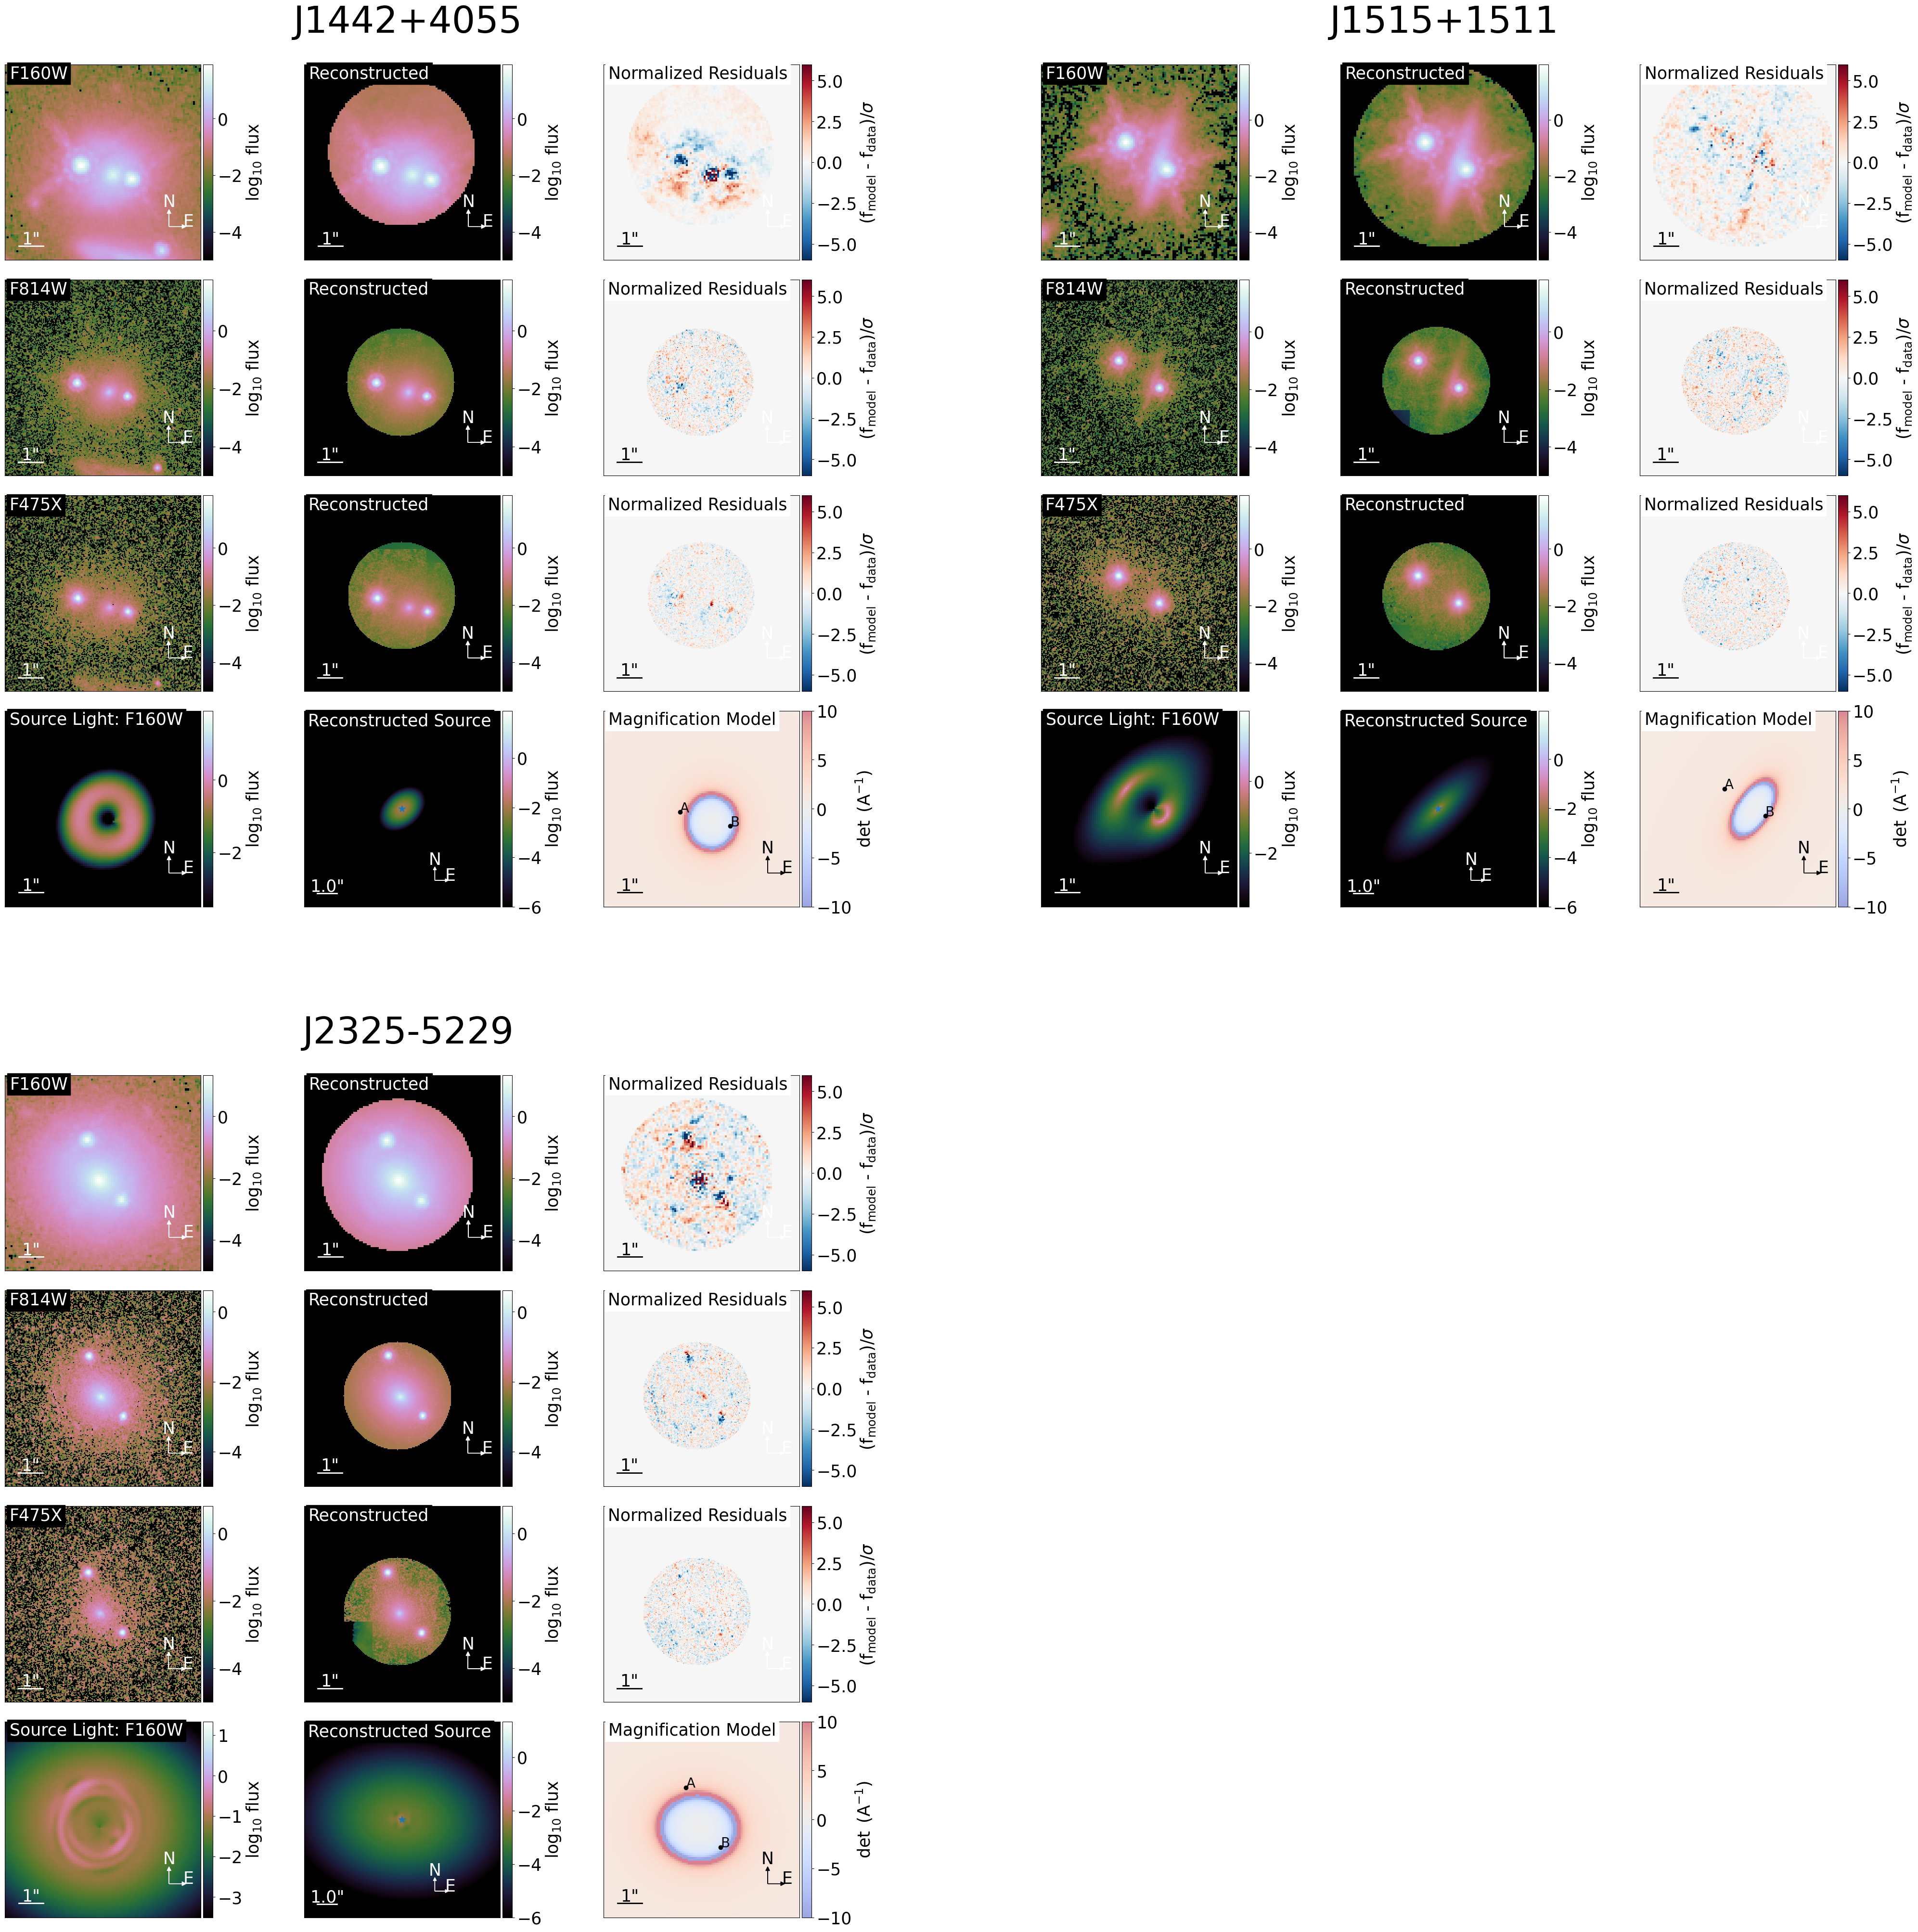

In [7]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from lenstronomy.Plots.model_plot import ModelPlot
import matplotlib.gridspec as gridspec

# Define systems and filters
systems = [
    ['J1442+4055', 'J1515+1511'],      # top row
    ['J2325-5229']                     # bottom row: only 1 system
]
filters = ['F160W', 'F814W', 'F475X']
fontsize = 25

# Create figure and outer GridSpec (2x2) 
fig = plt.figure(figsize=(50, 50))

outer_gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    wspace=0.25,
    hspace=0.2
)

# Loop through outer grid
for row_block, system_pair in enumerate(systems):
    for col_block in range(2):   # ensure 2 columns exist
        # Skip missing system positions
        if col_block >= len(system_pair) or system_pair[col_block] is None:
            continue

        name = system_pair[col_block]

        # Inner grid for each system
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            4, 3,
            subplot_spec=outer_gs[row_block, col_block],
            wspace=0.3,
            hspace=0.1
        )

        # Add system name centered above this block
        bbox = outer_gs[row_block, col_block].get_position(fig)
        fig.text(
            x=0.5 * (bbox.x0 + bbox.x1),
            y=bbox.y1 + 0.01,
            s=name,
            ha='center',
            va='bottom',
            fontsize=55,
            #fontweight='bold'
        )


        # Load data
        filename = f"../joint_modeling/{name}/{name}_joint.pkl"
        with open(filename, "rb") as f:
            loaded_data = pickle.load(f)

        kwargs_result = loaded_data["kwargs_result"]
        multi_band_list = loaded_data["multi_band_list"]
        kwargs_model = loaded_data["kwargs_model"]
        mask_list = loaded_data['kwargs_likelihood']['image_likelihood_mask_list']

        modelPlot = ModelPlot(
            multi_band_list,
            kwargs_model,
            kwargs_result,
            image_likelihood_mask_list=mask_list,
            arrow_size=0.02,
            cmap_string="cubehelix"
        )

        # Plot filter rows
        for i, filter in enumerate(filters):

            ax_data = fig.add_subplot(inner_gs[i, 0])
            ax_model = fig.add_subplot(inner_gs[i, 1])
            ax_resid = fig.add_subplot(inner_gs[i, 2])

            modelPlot.data_plot(ax=ax_data, text=f'{filter}', font_size=fontsize, band_index=i)
            modelPlot.model_plot(ax=ax_model, font_size=fontsize, band_index=i)
            modelPlot.normalized_residual_plot(
                ax=ax_resid, v_min=-6, v_max=6,
                font_size=fontsize, band_index=i, cmap='RdBu_r'
            )

        # Decomposition / source / magnification row
        ax_decomp = fig.add_subplot(inner_gs[3, 0])
        ax_conv   = fig.add_subplot(inner_gs[3, 1])
        ax_mag    = fig.add_subplot(inner_gs[3, 2])

        modelPlot.decomposition_plot(
            ax=ax_decomp,
            text="Source Light: F160W",
            font_size=25,
            source_add=True,
            unconvolved=True,
            v_min=-3.5,
            band_index=0
        )

        modelPlot.source_plot(
            ax=ax_conv, text="Reconstructed Source",
            deltaPix_source=0.01, numPix=1000, v_min=-6.,
            scale_size=1, font_size=fontsize, band_index=0,
            cmap='gist_heat'
        )

        modelPlot.magnification_plot(
            ax=ax_mag,
            text='Magnification Model',
            cmap='coolwarm',
            font_size=fontsize,
            band_index=0
        )

# Save + show
#plt.savefig('three_models.png')
plt.show()
